Import library

In [72]:
import pandas as pd
import re
import glob
import yaml

In [73]:
with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

Load Log File

In [74]:
def parse_nginx_raw(filepath: str) -> pd.DataFrame:
    with open(filepath, "r") as f:
        lines = f.readlines()
    return pd.DataFrame({"raw_log": lines})

In [75]:
import os

log_files = glob.glob("../data/raw/access.log.*")

dfs = []

for file in log_files:
    df = parse_nginx_raw(file)
    dfs.append(df)

logs = pd.concat(dfs, ignore_index=True)

print("Total logs:", len(logs))

Total logs: 23134


In [76]:
log_pattern = re.compile(
    r'(?P<ip>\S+) - - \[(?P<time>.*?)\] '
    r'"(?P<method>\S+) (?P<endpoint>\S+) (?P<protocol>.*?)" '
    r'(?P<status>\d+) (?P<size>\d+) '
    r'"(?P<referer>.*?)" "(?P<user_agent>.*?)" '
    r'X-Forwarded-For="(?P<real_ip>.*?)"'
)

In [77]:
records = logs["raw_log"].apply(
    lambda log: log_pattern.search(log).groupdict()
    if log_pattern.search(log) else None
)

df = pd.DataFrame(records.dropna().tolist())

df.head()

,ip,time,method,endpoint,protocol,status,size,referer,user_agent,real_ip
0,127.0.0.1,06/May/2025:00:00:21 +0000,POST,/api/v1/auths/login,HTTP/1.1,401,62,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,175.45.188.252
1,127.0.0.1,06/May/2025:00:00:22 +0000,POST,/api/v1/auths/login,HTTP/1.1,401,62,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,175.45.188.252
2,127.0.0.1,06/May/2025:00:00:22 +0000,POST,/api/v1/auths/login,HTTP/1.1,200,33,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,175.45.188.252
3,127.0.0.1,06/May/2025:00:00:22 +0000,POST,/api/v1/auths/login,HTTP/1.1,200,33,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,175.45.188.252
4,127.0.0.1,06/May/2025:00:00:23 +0000,POST,/api/v1/auths/login,HTTP/1.1,200,33,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,175.45.188.252


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23133 entries, 0 to 23132
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ip          23133 non-null  str  
 1   time        23133 non-null  str  
 2   method      23133 non-null  str  
 3   endpoint    23133 non-null  str  
 4   protocol    23133 non-null  str  
 5   status      23133 non-null  str  
 6   size        23133 non-null  str  
 7   referer     23133 non-null  str  
 8   user_agent  23133 non-null  str  
 9   real_ip     23133 non-null  str  
dtypes: str(10)
memory usage: 1.8 MB


In [79]:
df["size"] = pd.to_numeric(df["size"], errors="coerce")

## Explore

In [80]:
df["method"].value_counts()

method
POST       17780
GET         5167
OPTIONS      140
DELETE        32
PATCH          8
PUT            3
HEAD           2
TRACK          1
Name: count, dtype: int64

In [81]:
df["status"].value_counts()

status
401    12991
200     6968
304     2802
204      140
400      133
500       31
403       28
404       24
405        6
201        5
499        4
409        1
Name: count, dtype: int64

In [82]:
df["endpoint"].value_counts().head(10)

endpoint
/api/v1/auths/login                        17744
/api/v1/books?search=&page=1&size=9          181
/api/v1/users/me                             139
/@vite/client                                 95
/src/main.tsx                                 95
/@react-refresh                               94
/src/App.tsx                                  94
/src/pages/admin/books/create/index.tsx       94
/src/pages/books/index.tsx                    94
/src/pages/book/comments.tsx                  94
Name: count, dtype: int64

In [83]:
df["real_ip"].value_counts().head(10)

real_ip
175.45.188.252    18155
175.45.191.10       836
175.45.191.9        568
175.45.191.19       543
175.45.191.14       530
125.166.13.115      419
175.45.191.11       332
175.45.191.8        327
175.45.191.15       281
175.45.190.3        249
Name: count, dtype: int64

<Axes: xlabel='time'>

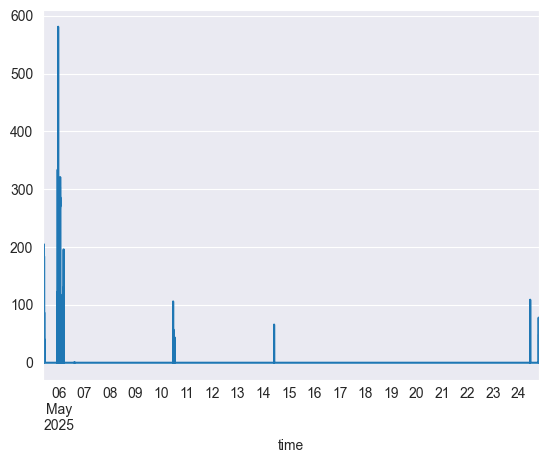

In [84]:
df["time"] = pd.to_datetime(df["time"], format="%d/%b/%Y:%H:%M:%S %z")

# resample per menit
df.set_index("time").resample("1min").size().plot()

<Axes: xlabel='time'>

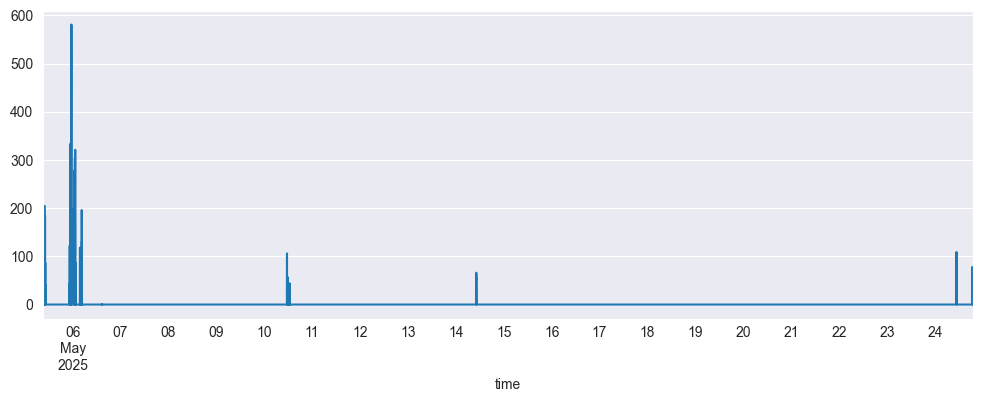

In [85]:
req_per_min = df.set_index("time").resample("1min").size()

rolling_mean = req_per_min.rolling(10).mean()
rolling_std = req_per_min.rolling(10).std()

zscore = (req_per_min - rolling_mean) / rolling_std

anomaly = zscore[zscore > 3]

req_per_min.plot(figsize=(12,4))

In [86]:
ip_rate = (
    df.set_index("time")
      .groupby("ip")
      .resample("1min")
      .size()
      .reset_index(name="count")
)

ip_rate.sort_values("count", ascending=False).head()

,ip,time,count
856,127.0.0.1,2025-05-05 23:23:00+00:00,581
855,127.0.0.1,2025-05-05 23:22:00+00:00,544
857,127.0.0.1,2025-05-05 23:24:00+00:00,543
854,127.0.0.1,2025-05-05 23:21:00+00:00,543
853,127.0.0.1,2025-05-05 23:20:00+00:00,543


In [87]:
pivot = pd.crosstab(df["endpoint"], df["status"])

pivot.head()

status,200,201,204,304,400,401,403,404,405,409,499,500
endpoint,,,,,,,,,,,,
/,21,0,0,0,0,0,0,1,0,0,0,0
/.well-known/security.txt,1,0,0,0,0,0,0,0,0,0,0,0
/?token=Kp5rLtCf5Hrs,90,0,0,0,0,0,0,0,0,0,0,0
/?token=dgb-pC_-nXzH,11,0,0,0,0,0,0,0,0,0,0,0
/@react-refresh,17,0,0,77,0,0,0,0,0,0,0,0


<Axes: xlabel='status', ylabel='endpoint'>

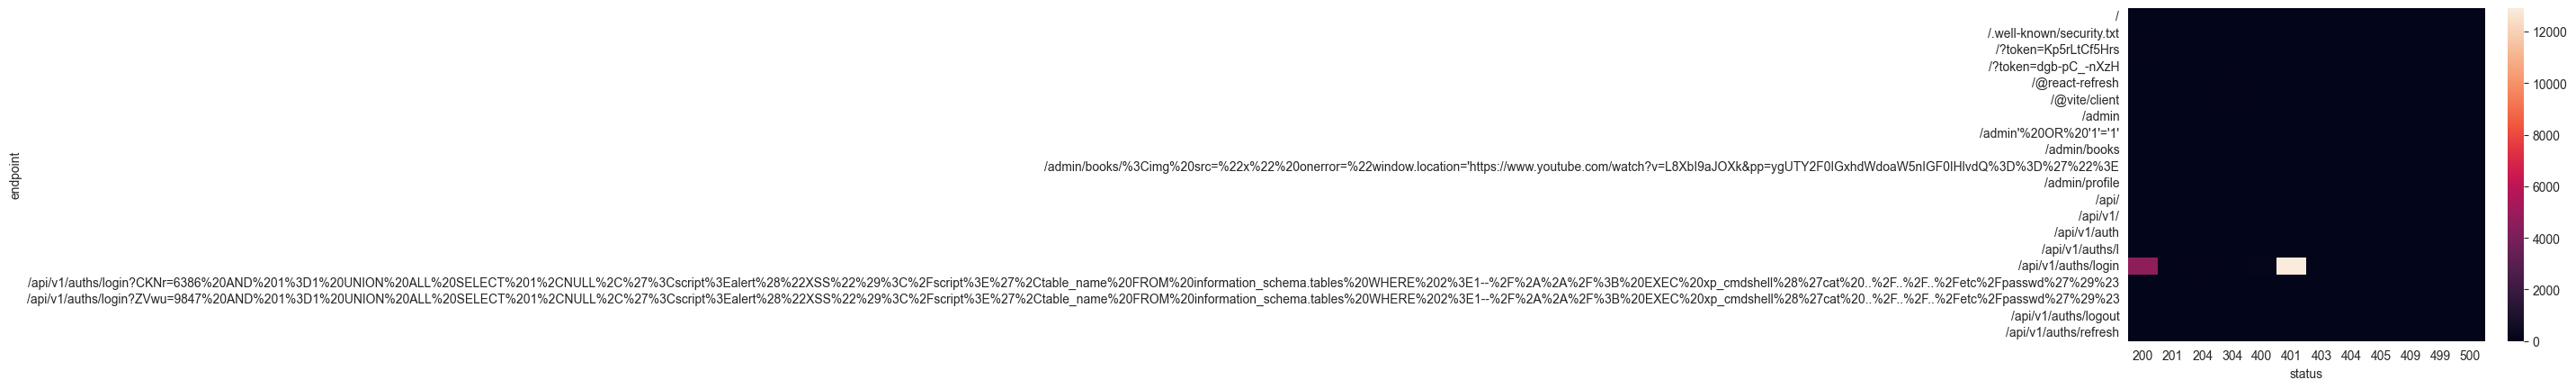

In [88]:
import seaborn as sns
sns.heatmap(pivot.head(20))

<Axes: ylabel='Frequency'>

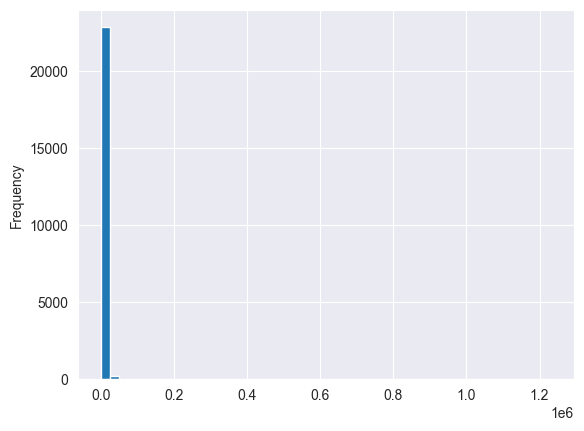

In [89]:
df["size"].describe()
df["size"].plot(kind="hist", bins=50)

## Save

In [90]:
df["ip"] = df["real_ip"]

df["endpoint_length"] = df["endpoint"].str.len()

df["param_count"] = df["endpoint"].str.count("&")

df["has_query"] = df["endpoint"].str.contains("\?").astype(int)

df["attack"] = 0

nginx_df = df[
    [
        "ip",
        "method",
        "endpoint",
        "status",
        "endpoint_length",
        "param_count",
        "has_query",
        "attack"
    ]
]

In [91]:
nginx_df["has_sql"] = df["endpoint"].str.contains(
    "select|union|drop|insert|or 1=1",
    case=False,
    regex=True
).astype(int)

nginx_df["has_script"] = df["endpoint"].str.contains(
    "<script>|%3Cscript",
    case=False
).astype(int)

nginx_df["has_path_traversal"] = df["endpoint"].str.contains(
    r"\.\./",
    regex=True
).astype(int)

In [92]:
raw_dir = config["data"]["processed_dir"]

nginx_parsed = os.path.join("..", raw_dir, "nginx_parsed.csv")

nginx_df.to_csv(nginx_parsed, index=False)